<a href="https://colab.research.google.com/github/arun-arunisto/ComputerVisionEngineering/blob/todo/ImageDescriptorUsingLocalBinaryPatterns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image Descriptor using LBP (Local Binary Patterns)

Using `sci-kit images` for implementing *LBP*. Because they offer more control types of LBP histograms to generate and `scikit-image` implementation also includes variants of LBPs that improve rotation and grayscale invariance.

For this classification i am using the sample dataset created by me with 4 photos of each my `laptop`, `pen`, `water bottle` and `book`. and i am saving into the folder like `dataset/train/laptop`, `dataset/train/pen`, `dataset/train/water_bottle`, `dataset/train/book`. And in `test` for i am just adding 4 images.

First we're going to create a class to get the LBP from an image using scikit

In [11]:
#local binary patterns
from skimage import feature
import numpy as np

class LocalBinaryPatterns:
  def __init__(self, numPoints, radius):
    self.numPoints = numPoints
    self.radius = radius
  def describe(self, image, eps=1e-7):
    lbp = feature.local_binary_pattern(image, self.numPoints, self.radius, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, self.numPoints + 3), range=(0, self.numPoints + 2))
    #normalizing the histogram
    hist = hist.astype("float")
    hist /= (hist.sum() + eps)
    #returning the histogram of LBP
    return hist

Now our LBP is defined, now we will use this to recognize texture and patterns

In [12]:
#importing nescessary packages
from sklearn.svm import LinearSVC
from imutils import paths
import cv2


desc = LocalBinaryPatterns(24, 8)
data = []
labels = []

Extracting LBP features from our training images

In [13]:
import os

for imgpath in paths.list_images("/content/drive/MyDrive/data/lbp_dataset/train"):
  # print(imgpath.split(os.path.sep)[-2])
  img = cv2.imread(imgpath)
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  hist = desc.describe(gray)
  labels.append(imgpath.split(os.path.sep)[-2])
  data.append(hist)

Training a Linear SVC with the data

In [14]:
model = LinearSVC(C=100.0, random_state=42)
model.fit(data, labels)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=100.0, random_state=42)

After training using it for the classification

In [40]:
img_test = cv2.imread("/content/drive/MyDrive/data/lbp_dataset/test/IMG_20241113_122347706.jpg")

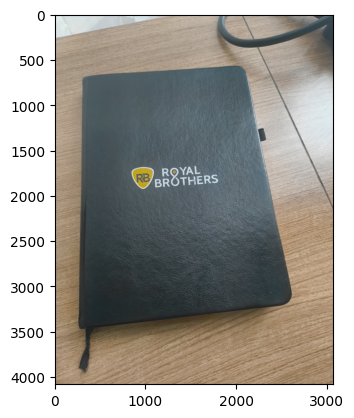

In [20]:
import matplotlib.pyplot as plt
plt.imshow(img_test[:, :, ::-1])

Going to use the above image for classification using model

In [22]:
#converting image to gray
gray = cv2.cvtColor(img_test, cv2.COLOR_BGR2GRAY)

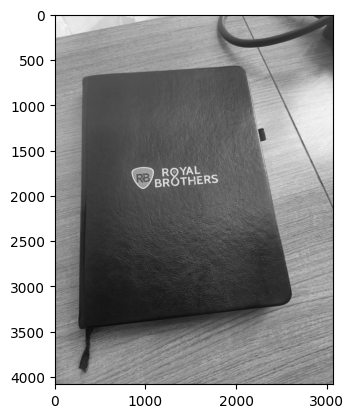

In [23]:
plt.imshow(gray, cmap="gray")

In [24]:
#getting the LBP
hist = desc.describe(gray)
print(hist)

[0.04459324 0.03607728 0.01813582 0.00986631 0.00591698 0.0040497
 0.00321348 0.00311104 0.00338693 0.00421079 0.00573132 0.00905243
 0.01366206 0.01009944 0.00647986 0.00465351 0.00344661 0.0032229
 0.00304442 0.00389325 0.00579515 0.01052047 0.01982565 0.03935411
 0.04871188 0.67994536]


In [25]:
#predicting using trained model
prediction = model.predict(hist.reshape(1, -1))
print(prediction)

['book']


Predicted correctly

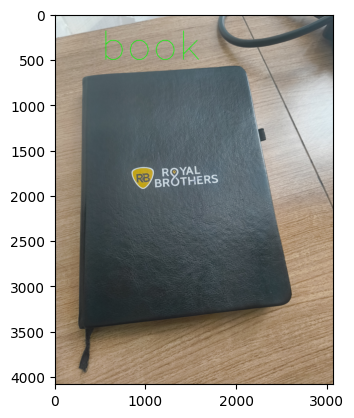

In [41]:
cv2.putText(img_test, prediction[0], (500, 500), cv2.FONT_HERSHEY_SIMPLEX, 15, (0, 255, 0), 5, cv2.LINE_AA)
plt.imshow(img_test[:, :, ::-1])

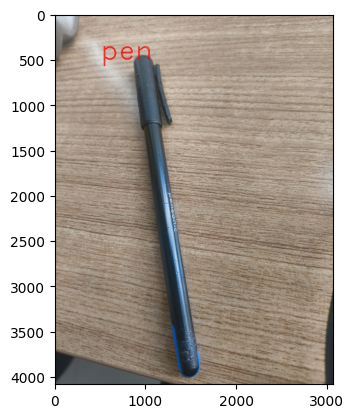

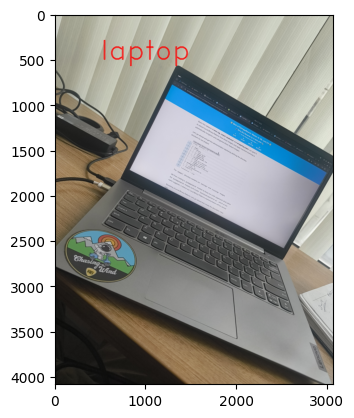

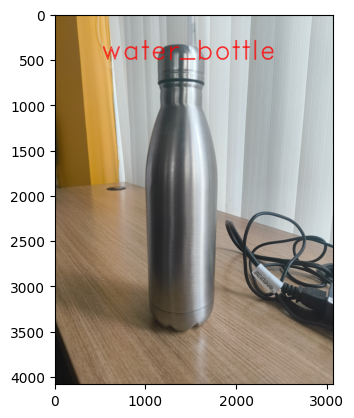

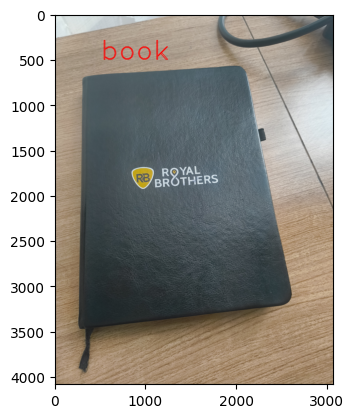

In [44]:
#testing all images
for imgpath in paths.list_images("/content/drive/MyDrive/data/lbp_dataset/test"):
  img_test = cv2.imread(imgpath)
  gray = cv2.cvtColor(img_test, cv2.COLOR_BGR2GRAY)
  hist = desc.describe(gray)
  prediction = model.predict(hist.reshape(1, -1))
  cv2.putText(img_test, prediction[0], (500, 500), cv2.FONT_HERSHEY_DUPLEX, 10, (0, 0, 255), 5, cv2.LINE_AA)
  plt.imshow(img_test[:, :, ::-1])
  plt.show()